# 2.4 Layout

CuTe uses a shape $S$ and a stride $D$ to define a layout function, or just layout. The shape $S$ defines the domain(s) of the layout function, while the stride $D$ defines the codomain of the layout function.

An alternate interpretation of the shape presented previously is that it is a map from the set of all coordinate lists to the natural coordinates. This map is bijective so that each coordinate is mapped to a unique and equivalent natural coordinate within the shape. Similarly, a stride is a map from the natural coordinates of a shape to some codomain.

$$S : \mathbb{Z} \leftrightarrow \mathbb{Z}_S, \quad \forall Z \in \mathcal{Z}(S)$$
$$D : \mathbb{Z}_S \to D$$

The $\leftrightarrow$ are the functions `idx2crd` and `crd2idx` that map between natural coordinates of compatible shapes, while the $\to$ mapping is the `inner_product` between a natural coordinate and the stride.

The composition of the shape and the stride defines the layout function, which is a map from the set of all coordinate lists to the codomain.

**Definition 2.17.** A layout $L = D \circ S$ is the functional composition of a shape $S$ and a stride $D$, where $S \sim D$, and defines a mapping $Z \to D$ for each $Z \in \mathcal{Z}(S)$.

In [1]:
from tensor_layouts import Layout, size, cosize, rank, depth, mode, flatten, coalesce
from tensor_layouts import idx2crd, crd2flat, crd2offset
from tensor_layouts import prefix_product, suffix_product
from tensor_layouts.viz import draw_layout, show_layout

## 2.4.1 Notations and Operations

We write layouts $L$ in different notations depending on context. For instance:

$$\frac{(4, (3, 2))}{(2, (8, 1))} = \frac{S}{D} \quad \text{or} \quad (4, (3, 2)) : (2, (8, 1)) = S : D \quad \text{or} \quad (2, (8, 1)) \circ (4, (3, 2)) = D \circ S$$

where the last style emphasizes that the shape and stride themselves can be interpreted as functions that compose to define the layout function.

Since the domain(s) of a layout are determined by its shape, layout properties align closely with shape properties. For layouts $L = S : D$ and $U = X : Y$, we define:

- $\text{rank}(L) = \text{rank}(S)$: The rank of a layout is the rank of its shape.
- $\text{depth}(L) = \text{depth}(S)$: The depth of a layout is the depth of its shape.
- $|L| = |S|$: The size of a layout is the size of its shape.
- $L_i = S_i : D_i$: The $i$th sublayout is constructed from the $i$th element of its shape and stride.
- $\mathcal{Z}(L) = \mathcal{Z}(S)$: The coordinate sets of a layout are the coordinate sets of its shape.
- $L \sim U \Leftrightarrow S \sim X$: The congruence of two layouts is the congruence of their shapes.
- $L \preceq U \Leftrightarrow S \preceq X$: The compatibility of two layouts is the compatibility of their shapes.

In [2]:
# Demonstrate layout properties
L = Layout(((2, 2), (4, 2)), ((1, 8), (2, 16)))
print(f"Layout L = {L}")
print(f"  rank(L)  = {rank(L)}")
print(f"  depth(L) = {depth(L)}")
print(f"  size(L)  = {size(L)}")
print(f"  cosize(L)= {cosize(L)}")
print(f"  mode 0:    {mode(L, 0)}")
print(f"  mode 1:    {mode(L, 1)}")

Layout L = ((2, 2), (4, 2)) : ((1, 8), (2, 16))
  rank(L)  = 2
  depth(L) = 2
  size(L)  = 32
  cosize(L)= 32
  mode 0:    (2, 2) : (1, 8)
  mode 1:    (4, 2) : (2, 16)


As an example of layout evaluation, consider the layout $L = ((2, 2), (4, 2)) : ((1, 8), (2, 16))$ from Figure 3e and the integral coordinate $22 \in \mathbb{Z}_{32} \in \mathcal{Z}(L)$, then

$$L(22) = L(2, 5) = L((0, 1), (1, 1)) = 26$$

where we have shown the integral coordinate, the equivalent 2D coordinate, the equivalent natural coordinate, and the computed offset.

In [3]:
# Trace the evaluation: integral -> 2D -> natural -> offset
L = Layout(((2, 2), (4, 2)), ((1, 8), (2, 16)))

# 1D integral coordinate
offset_1d = L(22)
print(f"L(22) = {offset_1d}")

# 2D coordinate: idx2crd maps 22 -> (2, 5) using the top-level shape (4, 8)
crd_2d = idx2crd(22, (4, 8))   # colexicographic: (22 % 4, 22 // 4) = (2, 5)
print(f"idx2crd(22, (4,8)) = {crd_2d}")
offset_2d = L(*crd_2d)
print(f"L(2, 5) = {offset_2d}")

# Natural coordinate: idx2crd maps 22 -> ((0,1), (1,1)) using the full shape
crd_nat = idx2crd(22, ((2, 2), (4, 2)))
print(f"idx2crd(22, ((2,2),(4,2))) = {crd_nat}")

# The offset: inner product of natural coord and stride
# (0*1 + 1*8) + (1*2 + 1*16) = 0 + 8 + 2 + 16 = 26
print(f"Manual: 0*1 + 1*8 + 1*2 + 1*16 = {0*1 + 1*8 + 1*2 + 1*16}")

assert offset_1d == offset_2d == 26

L(22) = 26
idx2crd(22, (4,8)) = (2, 5)
L(2, 5) = 26
idx2crd(22, ((2,2),(4,2))) = ((0, 1), (1, 1))
Manual: 0*1 + 1*8 + 1*2 + 1*16 = 26


The in-bounds domain of a layout is the set of all coordinates $c \in \mathcal{Z}(L)$. Layouts can also be evaluated on out-of-bounds coordinates, analogous to arrays that can be evaluated on out-of-bounds indices with undefined behavior. So while the domain of a layout is the finite set $\mathcal{Z}(L)$, the extended domain is the infinite set $\mathbb{Z}_L$ of all `HTuple(Z)` that are weakly congruent with $S$.

We also make the distinction between the codomain and the image of a layout. The codomain of a layout is $D$, which is often infinite (for instance, $\mathbb{Z}$ or $\mathbb{Z}_D$). The image of a layout is finite and is the range of values the layout produces for all coordinates in the domain.

$$\text{image}(L) = L(\mathcal{Z}(L)) = L(\mathbb{Z}_{|L|}) \subseteq \text{codomain}(L)$$

In [4]:
# Demonstrate the image of a layout
# For a simple column-major layout, the image is {0, 1, ..., size-1}
L_col = Layout((4, 8), (1, 4))
image_col = sorted({L_col(i) for i in range(size(L_col))})
print(f"Col-major {L_col}")
print(f"  size = {size(L_col)}, cosize = {cosize(L_col)}")
print(f"  image = {image_col}")
print(f"  |image| = {len(image_col)} (injective: image size == layout size)")
print()

# For a broadcast layout, the image is smaller than the size
L_bcast = Layout(((2, 2), (2, 4)), ((0, 2), (0, 4)))
image_bcast = sorted({L_bcast(i) for i in range(size(L_bcast))})
print(f"Broadcast {L_bcast}")
print(f"  size = {size(L_bcast)}, cosize = {cosize(L_bcast)}")
print(f"  image = {image_bcast}")
print(f"  |image| = {len(image_bcast)} (not injective: image size < layout size)")

Col-major (4, 8) : (1, 4)
  size = 32, cosize = 32
  image = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
  |image| = 32 (injective: image size == layout size)

Broadcast ((2, 2), (2, 4)) : ((0, 2), (0, 4))
  size = 32, cosize = 15
  image = [0, 2, 4, 6, 8, 10, 12, 14]
  |image| = 8 (not injective: image size < layout size)


## 2.4.2 Layout Examples

Having defined shapes, strides, and layouts, we now present examples that demonstrate CuTe layouts are a strict generalization of common flat N-dimensional layouts.

Figure 3 illustrates examples of data layouts commonly encountered in dense linear algebra libraries, such as CUTLASS. Each layout is represented as a mapping from logical coordinates $(m, n) \in \mathcal{Z}_{(4,8)}$ to an offset $k \in \mathbb{Z}$. These offsets can, for instance, be used to index elements within a data array. The common row-major, column-major, and padded layouts are trivially represented by CuTe layouts, while the interleaved and mixed layouts demonstrate that the representation set of layouts is strictly expanded by using nested shapes and strides. In particular, it is clear that grids-of-tiles-of-data are immediately representable with CuTe layouts.

(a) Col-Major: (4, 8) : (1, 4)
    size=32, cosize=32


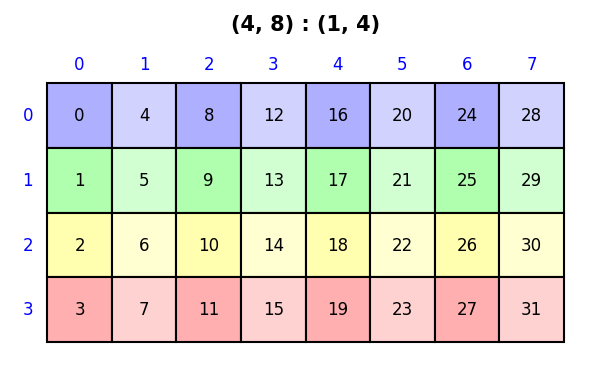

In [5]:
# (a) Col-Major: (4, 8) : (1, 4)
L_col = Layout((4, 8), (1, 4))
print(f"(a) Col-Major: {L_col}")
print(f"    size={size(L_col)}, cosize={cosize(L_col)}")
draw_layout(L_col, colorize=True)

(b) Row-Major: (4, 8) : (8, 1)
    size=32, cosize=32


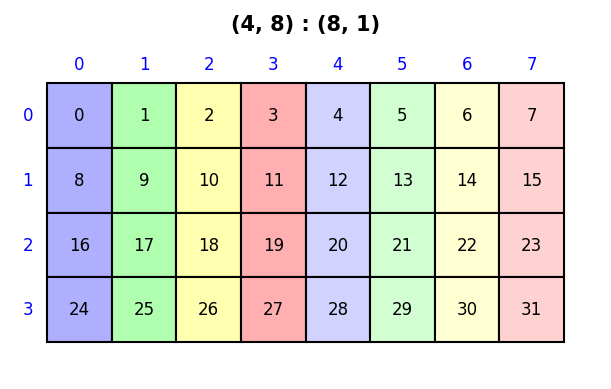

In [6]:
# (b) Row-Major: (4, 8) : (8, 1)
L_row = Layout((4, 8), (8, 1))
print(f"(b) Row-Major: {L_row}")
print(f"    size={size(L_row)}, cosize={cosize(L_row)}")
draw_layout(L_row, colorize=True)

(c) Col-Major Padded: (4, 8) : (1, 5)
    size=32, cosize=39
    Note: cosize (39) > size (32) due to padding


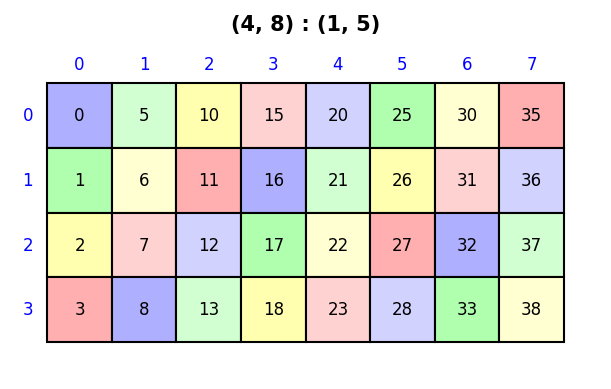

In [7]:
# (c) Col-Major Padded: (4, 8) : (1, 5)
# The stride of 5 (instead of 4) means there's a gap between columns
L_pad = Layout((4, 8), (1, 5))
print(f"(c) Col-Major Padded: {L_pad}")
print(f"    size={size(L_pad)}, cosize={cosize(L_pad)}")
print(f"    Note: cosize ({cosize(L_pad)}) > size ({size(L_pad)}) due to padding")
draw_layout(L_pad, colorize=True)

(d) Col-Major Interleave: (4, (4, 2)) : (4, (1, 16))
    size=32, cosize=32


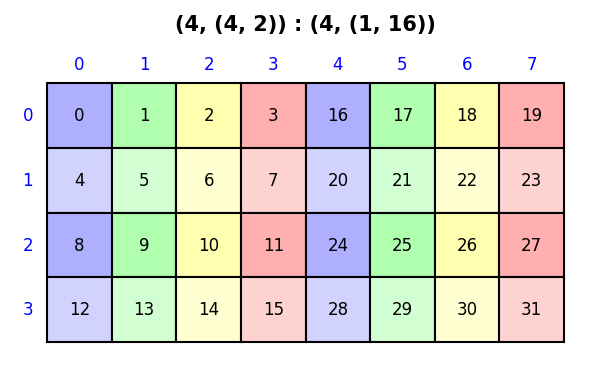

In [8]:
# (d) Col-Major Interleave: (4, (4, 2)) : (4, (1, 16))
# The column mode is hierarchical: 4 columns within a tile, 2 tiles
L_int = Layout((4, (4, 2)), (4, (1, 16)))
print(f"(d) Col-Major Interleave: {L_int}")
print(f"    size={size(L_int)}, cosize={cosize(L_int)}")
draw_layout(L_int, colorize=True)

(e) Mixed: ((2, 2), (4, 2)) : ((1, 8), (2, 16))
    size=32, cosize=32


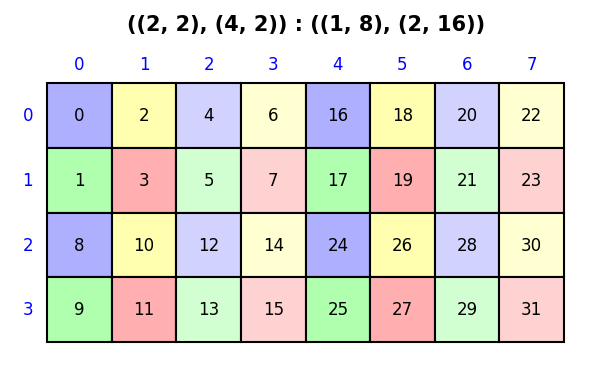

In [9]:
# (e) Mixed: ((2, 2), (4, 2)) : ((1, 8), (2, 16))
# Both modes are hierarchical — a grid of tiles
L_mix = Layout(((2, 2), (4, 2)), ((1, 8), (2, 16)))
print(f"(e) Mixed: {L_mix}")
print(f"    size={size(L_mix)}, cosize={cosize(L_mix)}")
draw_layout(L_mix, colorize=True)

(f) Blocked Broadcast: ((2, 2), (2, 4)) : ((0, 2), (0, 4))
    size=32, cosize=15
    image = [0, 2, 4, 6, 8, 10, 12, 14] (only 8 distinct offsets out of 32)


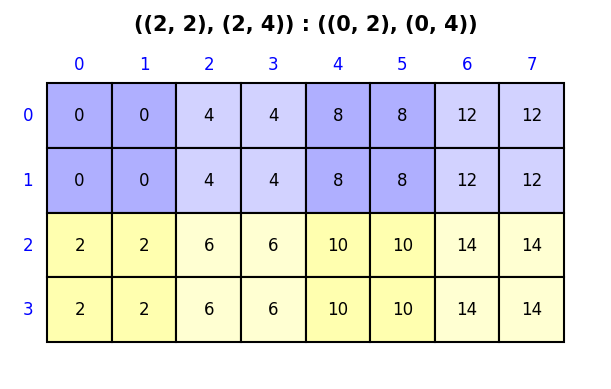

In [10]:
# (f) Blocked Broadcast: ((2, 2), (2, 4)) : ((0, 2), (0, 4))
# Zero strides cause repetition (broadcast)
L_blk = Layout(((2, 2), (2, 4)), ((0, 2), (0, 4)))
print(f"(f) Blocked Broadcast: {L_blk}")
print(f"    size={size(L_blk)}, cosize={cosize(L_blk)}")

image = sorted({L_blk(i) for i in range(size(L_blk))})
print(f"    image = {image} (only {len(image)} distinct offsets out of {size(L_blk)})")
draw_layout(L_blk, colorize=True)

## 2.4.3 Completeness

Every function $f$ with $f(0) = 0$ and finite domain $\mathbb{Z}_N$ can be represented as the functional composition of a finite sequence of CuTe layouts. This means that CuTe layouts are a generating set under functional composition. Such a function $f$ can be represented as a sequence of compositions

$$f \equiv (2, 2, 2, \ldots) : (f(1), f(2), f(3), \ldots) \circ (3, 1) : (1, 4) \circ (4, 1) : (1, 6) \circ \cdots \circ (N-1, 1) : (1, 2(N-2)).$$

For all $i \in \mathbb{Z}_N / \{0\}$, the rightmost $N-3$ layouts map $i \to 2^{i-1}$ and the leftmost layout maps $2^{i-1} \to f(i)$.

In [11]:
from tensor_layouts import compose

# Demonstrate the key insight of completeness.
#
# The paper's construction has two parts:
# 1. A chain of layouts that maps i -> 2^(i-1) for i >= 1 (using extended domain)
# 2. A "lookup table" layout (2,2,2,...) : (f(1),f(2),...) that maps 2^(i-1) -> f(i)
#
# The lookup table layout is the most interesting part. It works because
# input 2^(i-1) has exactly one bit set, selecting exactly one stride element.

# Target function: f = {0->0, 1->7, 2->3, 3->11, 4->2}
N = 5
f_values = {0: 0, 1: 7, 2: 3, 3: 11, 4: 2}

# The lookup table layout: shape (2,2,2,2), stride (f(1),f(2),f(3),f(4))
# Input 2^(i-1) selects stride element i (since bit i-1 is set)
lookup = Layout((2, 2, 2, 2), (f_values[1], f_values[2], f_values[3], f_values[4]))
print(f"Lookup layout: {lookup}")
print()

# Verify: lookup(2^(i-1)) = f(i) for i = 1..4
print("Lookup table evaluation:")
print(f"  lookup(0) = {lookup(0)} (f(0) = 0)")
for i in range(1, N):
    result = lookup(2**(i-1))
    print(f"  lookup(2^{i-1}) = lookup({2**(i-1)}) = {result} (f({i}) = {f_values[i]})")
    assert result == f_values[i]

print()
print("The key idea: any function f with f(0)=0 and finite domain can be")
print("represented as a composition of CuTe layouts, making them a generating")
print("set under functional composition.")

Lookup layout: (2, 2, 2, 2) : (7, 3, 11, 2)

Lookup table evaluation:
  lookup(0) = 0 (f(0) = 0)
  lookup(2^0) = lookup(1) = 7 (f(1) = 7)
  lookup(2^1) = lookup(2) = 3 (f(2) = 3)
  lookup(2^2) = lookup(4) = 11 (f(3) = 11)
  lookup(2^3) = lookup(8) = 2 (f(4) = 2)

The key idea: any function f with f(0)=0 and finite domain can be
represented as a composition of CuTe layouts, making them a generating
set under functional composition.


## 2.4.4 Semi-Linearity

The shape-stride definition, $L = D \circ S$, along with generalized integer-module strides yield a particularly useful linear-algebraic view of layout functions,

$$L(c) = (D \circ S)(c) = d \cdot S(c) = d \cdot e_c. \tag{7}$$

The shape function is a convenient semi-affine bijection into the natural coordinates, $e_c \in \mathbb{Z}_S$, and the stride function is a linear function of the natural coordinates. Indeed, for two natural coordinates $e_{c_0}, e_{c_1} \in \mathbb{Z}_S$, the layout function is linear,

$$L(\alpha e_{c_0} + \beta e_{c_1}) = d \cdot (\alpha e_{c_0} + \beta e_{c_1}) = \alpha(d \cdot e_{c_0}) + \beta(d \cdot e_{c_1}) = \alpha L(e_{c_0}) + \beta L(e_{c_1}),$$

because the shape function is the identity and the stride function is linear. Note that for arbitrary coordinates $c_0, c_1 \in \mathcal{Z}(S)$, the layout is not linear because the shape function is not linear,

$$e_c = S(c_0 + c_1) \neq S(c_0) + S(c_1) = e_{c_0} + e_{c_1}.$$

As a result, the layout function is linear in the natural coordinates, $e_c \in \mathbb{Z}_S$, but nonlinear in the arbitrary coordinates, $c \in \mathcal{Z}(S)$.

In [12]:
# Demonstrate semi-linearity of layouts
# Layout L = ((2, 2), (4, 2)) : ((1, 8), (2, 16))
# has natural coordinates e_c in Z_{(2,2,4,2)} — a flat 4-tuple
L = Layout(((2, 2), (4, 2)), ((1, 8), (2, 16)))
d = (1, 8, 2, 16)  # stride as flat tuple

# The layout is LINEAR in natural coordinates:
# L(alpha * e_c0 + beta * e_c1) = alpha * L(e_c0) + beta * L(e_c1)

# Pick two natural coordinates
e_c0 = (1, 0, 1, 0)  # natural coord -> offset = 1*1 + 0*8 + 1*2 + 0*16 = 3
e_c1 = (0, 1, 0, 1)  # natural coord -> offset = 0*1 + 1*8 + 0*2 + 1*16 = 24

def inner_product(d, e):
    return sum(di * ei for di, ei in zip(d, e))

def scale(alpha, e):
    return tuple(alpha * ei for ei in e)

def add(e0, e1):
    return tuple(a + b for a, b in zip(e0, e1))

alpha, beta = 3, 2

# LHS: L(alpha * e_c0 + beta * e_c1)
combined = add(scale(alpha, e_c0), scale(beta, e_c1))
lhs = inner_product(d, combined)

# RHS: alpha * L(e_c0) + beta * L(e_c1)
rhs = alpha * inner_product(d, e_c0) + beta * inner_product(d, e_c1)

print(f"d = {d}")
print(f"e_c0 = {e_c0}, L(e_c0) = d . e_c0 = {inner_product(d, e_c0)}")
print(f"e_c1 = {e_c1}, L(e_c1) = d . e_c1 = {inner_product(d, e_c1)}")
print(f"alpha={alpha}, beta={beta}")
print(f"alpha*e_c0 + beta*e_c1 = {combined}")
print(f"LHS: L(alpha*e_c0 + beta*e_c1) = {lhs}")
print(f"RHS: alpha*L(e_c0) + beta*L(e_c1) = {rhs}")
assert lhs == rhs
print("Linearity holds in natural coordinates!")

d = (1, 8, 2, 16)
e_c0 = (1, 0, 1, 0), L(e_c0) = d . e_c0 = 3
e_c1 = (0, 1, 0, 1), L(e_c1) = d . e_c1 = 24
alpha=3, beta=2
alpha*e_c0 + beta*e_c1 = (3, 2, 3, 2)
LHS: L(alpha*e_c0 + beta*e_c1) = 57
RHS: alpha*L(e_c0) + beta*L(e_c1) = 57
Linearity holds in natural coordinates!


In [13]:
# Demonstrate NON-linearity in arbitrary coordinates
# For a hierarchical shape like ((2,2), (4,2)), the shape function
# S: integer -> natural coordinate is NOT linear.
#
# S(c0 + c1) != S(c0) + S(c1)  in general

shape = ((2, 2), (4, 2))

# Pick two 1D coordinates
c0 = 3   # idx2crd(3, (4,8)) = (3, 0)
c1 = 5   # idx2crd(5, (4,8)) = (1, 1)

nat_c0 = idx2crd(c0, shape)  # natural coord of c0
nat_c1 = idx2crd(c1, shape)  # natural coord of c1
nat_sum = idx2crd(c0 + c1, shape)  # natural coord of c0+c1=8

print(f"c0 = {c0}, S(c0) = idx2crd({c0}, {shape}) = {nat_c0}")
print(f"c1 = {c1}, S(c1) = idx2crd({c1}, {shape}) = {nat_c1}")
print(f"c0 + c1 = {c0 + c1}")
print(f"S(c0 + c1) = idx2crd({c0+c1}, {shape}) = {nat_sum}")

# Compute S(c0) + S(c1) element-wise (flattening the nested tuples)
def flatten_tuple(t):
    if isinstance(t, (list, tuple)):
        for item in t:
            yield from flatten_tuple(item)
    else:
        yield t

flat_c0 = list(flatten_tuple(nat_c0))
flat_c1 = list(flatten_tuple(nat_c1))
flat_sum_expected = [a + b for a, b in zip(flat_c0, flat_c1)]
flat_actual = list(flatten_tuple(nat_sum))

print(f"\nS(c0) flat = {flat_c0}")
print(f"S(c1) flat = {flat_c1}")
print(f"S(c0) + S(c1) = {flat_sum_expected}")
print(f"S(c0 + c1)    = {flat_actual}")
print(f"S(c0+c1) == S(c0)+S(c1)? {flat_actual == flat_sum_expected}")
print("\nThe shape function is NOT linear in arbitrary coordinates!")
print("This is because idx2crd uses modular arithmetic (carries don't propagate linearly).")

c0 = 3, S(c0) = idx2crd(3, ((2, 2), (4, 2))) = ((1, 1), (0, 0))
c1 = 5, S(c1) = idx2crd(5, ((2, 2), (4, 2))) = ((1, 0), (1, 0))
c0 + c1 = 8
S(c0 + c1) = idx2crd(8, ((2, 2), (4, 2))) = ((0, 0), (2, 0))

S(c0) flat = [1, 1, 0, 0]
S(c1) flat = [1, 0, 1, 0]
S(c0) + S(c1) = [2, 1, 1, 0]
S(c0 + c1)    = [0, 0, 2, 0]
S(c0+c1) == S(c0)+S(c1)? False

The shape function is NOT linear in arbitrary coordinates!
This is because idx2crd uses modular arithmetic (carries don't propagate linearly).


In the natural coordinates, $d \cdot e_c$ can be interpreted as a generalized matrix-vector product,

$$L(c) = d \cdot e_c = D\, e_c$$

where $D$ is a matrix with elements selected from an integer-semimodule $\mathcal{D}$. In the most common case with integer strides, $\mathcal{D} = \mathbb{Z}$, this is a matrix-vector product with $D \in \mathbb{Z}^{1 \times n}$.

| $L$ | Linear Form: $r = D\, e_c$ | Comment |
|-----|-----|-----|
| $((2,2),(4,2)):((1,8),(2,16))$ | $r = [1\ 8\ 2\ 16] \begin{bmatrix} e_{c_0} \\ e_{c_1} \\ e_{c_2} \\ e_{c_3} \end{bmatrix}$ | Integer strides are columns of $1 \times n$ $\mathbb{Z}$-matrix |

In [14]:
# The linear form: r = D @ e_c
# For L = ((2,2),(4,2)):((1,8),(2,16)), D = [1 8 2 16] (a 1x4 matrix)
import numpy as np

L = Layout(((2, 2), (4, 2)), ((1, 8), (2, 16)))
D_matrix = np.array([[1, 8, 2, 16]])  # 1x4 matrix

print(f"Layout: {L}")
print(f"D matrix: {D_matrix}")
print()

# Verify: for every coordinate, L(c) = D @ e_c
print("Verifying L(c) = D @ e_c for all in-bounds coordinates:")
for c in range(size(L)):
    e_c = list(flatten_tuple(idx2crd(c, ((2, 2), (4, 2)))))
    offset_layout = L(c)
    offset_matrix = (D_matrix @ np.array(e_c)).item()
    assert offset_layout == offset_matrix

# Show a few examples
for c in [0, 1, 7, 15, 22, 31]:
    e_c = list(flatten_tuple(idx2crd(c, ((2, 2), (4, 2)))))
    r = (D_matrix @ np.array(e_c)).item()
    print(f"  c={c:2d}: e_c={e_c} -> r = [1 8 2 16] . {e_c} = {r}")

print(f"\nAll {size(L)} coordinates verified: L(c) = D @ e_c.")

Layout: ((2, 2), (4, 2)) : ((1, 8), (2, 16))
D matrix: [[ 1  8  2 16]]

Verifying L(c) = D @ e_c for all in-bounds coordinates:
  c= 0: e_c=[0, 0, 0, 0] -> r = [1 8 2 16] . [0, 0, 0, 0] = 0
  c= 1: e_c=[1, 0, 0, 0] -> r = [1 8 2 16] . [1, 0, 0, 0] = 1
  c= 7: e_c=[1, 1, 1, 0] -> r = [1 8 2 16] . [1, 1, 1, 0] = 11
  c=15: e_c=[1, 1, 3, 0] -> r = [1 8 2 16] . [1, 1, 3, 0] = 15
  c=22: e_c=[0, 1, 1, 1] -> r = [1 8 2 16] . [0, 1, 1, 1] = 26
  c=31: e_c=[1, 1, 3, 1] -> r = [1 8 2 16] . [1, 1, 3, 1] = 31

All 32 coordinates verified: L(c) = D @ e_c.
